In [151]:
!pip install networkx matplotlib pandas networkit imageio

In [74]:
import os
import time
import heapq
import shutil
import networkit as nk

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
[x for x in dir(nk) if "hier" in x.lower()]

[]

In [26]:
DATASETS = {
    "econ-wm1": {
        "path": "/content/econ-wm1.mtx",
        "snapshot_interval": 13
    },
    "econ-poli": {
        "path": "/content/econ-poli.mtx",
        "snapshot_interval": 110
    },
    "econ-mbeacxc": {
        "path": "/content/econ-mbeacxc.mtx",
        "snapshot_interval": 24
    },
    "econ-orani678": {
        "path": "/content/econ-orani678.mtx",
        "snapshot_interval": 126
    },
    "econ-psmigr1": {
        "path": "/content/econ-psmigr1.mtx",
        "snapshot_interval": 157
    }
} #larger datasets made way too many snapshots to reasonably download so we made "interval"
 #to only take some iterations and manually tweaked to aim for ~20 snapshots per graph

In [27]:
def load_graph(path):

    G = nx.Graph()

    with open(path, "r") as f:

        dimension_line_found = False

        for line in f:

            line = line.strip()

            if not line:
                continue

            if line.startswith("%"):
                continue

            parts = line.split()

            if not dimension_line_found:
                dimension_line_found = True
                continue

            if len(parts) < 3:
                continue

            u = int(parts[0])
            v = int(parts[1])

            w = abs(float(parts[2]))

            if u != v:
                G.add_edge(
                    u,
                    v,
                    weight=w
                )

    return G

In [28]:
def dijkstra_binary_heap(
    G,
    source,
    snapshot_interval=25
):

    distances = {
        node: float("inf")
        for node in G.nodes()
    }

    parent = {}

    distances[source] = 0

    pq = [(0, source)]

    visited = set()

    snapshots = []

    while pq:

        current_dist, u = heapq.heappop(pq)

        if u in visited:
            continue

        visited.add(u)

        if len(visited) % snapshot_interval == 0:
            snapshots.append(
                parent.copy()
            )

        for v in G.neighbors(u):

            weight = G[u][v]["weight"]

            new_dist = current_dist + weight

            if new_dist < distances[v]:

                distances[v] = new_dist

                parent[v] = u

                heapq.heappush(
                    pq,
                    (new_dist, v)
                )

    snapshots.append(parent.copy())

    return distances, parent, snapshots

In [122]:
def bidirectional_dijkstra(
    G,
    source,
    snapshot_interval = 25):

    nodes = list(G.nodes())

    target = nodes[-1]

    dist_f = {
        node: float("inf")
        for node in G.nodes()
    }

    dist_b = {
        node: float("inf")
        for node in G.nodes()
    }

    parent_f = {}
    parent_b = {}

    dist_f[source] = 0
    dist_b[target] = 0

    pq_f = [(0, source)]
    pq_b = [(0, target)]

    visited_f = set()
    visited_b = set()

    snapshots = []

    meeting_node = None

    while pq_f and pq_b:



        d_f, u = heapq.heappop(pq_f)

        if u not in visited_f:

            visited_f.add(u)

            if (True):
                snapshots.append(
                    parent_f.copy()
                )

            if u in visited_b:

                meeting_node = u
                break

            for v in G.neighbors(u):

                w = G[u][v]["weight"]

                nd = d_f + w

                if nd < dist_f[v]:

                    dist_f[v] = nd
                    parent_f[v] = u

                    heapq.heappush(
                        pq_f,
                        (nd, v)
                    )



        d_b, u = heapq.heappop(pq_b)

        if u not in visited_b:

            visited_b.add(u)

            if u in visited_f:

                meeting_node = u
                break

            for v in G.neighbors(u):

                w = G[u][v]["weight"]

                nd = d_b + w

                if nd < dist_b[v]:

                    dist_b[v] = nd
                    parent_b[v] = u

                    heapq.heappush(
                        pq_b,
                        (nd, v)
                    )

    snapshots.append(
        parent_f.copy()
    )

    return (
        dist_f,
        parent_f,
        snapshots
    )

In [123]:
def select_landmarks(G, k=4):

    nodes = list(G.nodes())

    if len(nodes) <= k:
        return nodes

    step = max(1, len(nodes) // k)

    return [
        nodes[i]
        for i in range(
            0,
            len(nodes),
            step
        )
    ][:k]

def preprocess_landmarks(
    G,
    landmarks
):

    landmark_distances = {}

    for landmark in landmarks:

        distances = nx.single_source_dijkstra_path_length(
            G,
            landmark,
            weight="weight"
        )

        landmark_distances[
            landmark
        ] = distances

    return landmark_distances

def alt_heuristic(
    node,
    target,
    landmark_distances,
    landmarks
):

    best = 0

    for landmark in landmarks:

        d_landmark_target = (
            landmark_distances[landmark]
            .get(target, float("inf"))
        )

        d_landmark_node = (
            landmark_distances[landmark]
            .get(node, float("inf"))
        )

        h = abs(
            d_landmark_target
            - d_landmark_node
        )

        if h > best:
            best = h

    return best

def alt_algorithm(
    G,
    source,
    snapshot_interval=25
):

    landmarks = select_landmarks(G)

    landmark_distances = (
        preprocess_landmarks(
            G,
            landmarks
        )
    )

    target = list(G.nodes())[-1]

    distances = {
        node: float("inf")
        for node in G.nodes()
    }

    parent = {}

    distances[source] = 0

    pq = [(
        0,
        source
    )]

    visited = set()

    snapshots = []

    while pq:

        _, u = heapq.heappop(pq)

        if u in visited:
            continue

        visited.add(u)

        if (
            len(visited)
            % snapshot_interval
            == 0
        ):
            snapshots.append(
                parent.copy()
            )

        for v in G.neighbors(u):

            weight = (
                G[u][v]["weight"]
            )

            new_dist = (
                distances[u]
                + weight
            )

            if (
                new_dist
                < distances[v]
            ):

                distances[v] = (
                    new_dist
                )

                parent[v] = u

                heuristic = (
                    alt_heuristic(
                        v,
                        target,
                        landmark_distances,
                        landmarks
                    )
                )

                priority = (
                    new_dist
                    + heuristic
                )

                heapq.heappush(
                    pq,
                    (
                        priority,
                        v
                    )
                )

    snapshots.append(
        parent.copy()
    )

    return (
        distances,
        parent,
        snapshots
    )

In [124]:
def build_hierarchy(G):

    degrees = dict(G.degree())

    degree_values = sorted(
        degrees.values()
    )

    high_cutoff = degree_values[
        int(0.9 * len(degree_values))
    ]

    mid_cutoff = degree_values[
        int(0.7 * len(degree_values))
    ]

    levels = {}

    for node, deg in degrees.items():

        if deg >= high_cutoff:
            levels[node] = 2

        elif deg >= mid_cutoff:
            levels[node] = 1

        else:
            levels[node] = 0

    return levels

def multilevel_dijkstra(
    G,
    source,
    snapshot_interval=25
):

    levels = build_hierarchy(G)

    distances = {
        node: float("inf")
        for node in G.nodes()
    }

    parent = {}

    distances[source] = 0

    visited = set()

    snapshots = []

    pq = [
        (
            0,
            -levels[source],
            source
        )
    ]

    while pq:

        dist_u, _, u = heapq.heappop(
            pq
        )

        if u in visited:
            continue

        visited.add(u)

        if (
            len(visited)
            % snapshot_interval
            == 0
        ):
            snapshots.append(
                parent.copy()
            )

        for v in G.neighbors(u):

            weight = (
                G[u][v]["weight"]
            )

            nd = (
                distances[u]
                + weight
            )

            if nd < distances[v]:

                distances[v] = nd

                parent[v] = u

                heapq.heappush(
                    pq,
                    (
                        nd,
                        -levels[v],
                        v
                    )
                )

    snapshots.append(
        parent.copy()
    )

    return (
        distances,
        parent,
        snapshots
    )

In [125]:
def nx_to_nk(G):

    nkG = nk.Graph(
        G.number_of_nodes(),
        weighted=True,
        directed=False
    )

    node_map = {
        node:i
        for i,node in enumerate(G.nodes())
    }

    reverse_map = {
        i:node
        for node,i in node_map.items()
    }

    for u,v,data in G.edges(data=True):

        nkG.addEdge(
            node_map[u],
            node_map[v],
            data["weight"]
        )

    return nkG,node_map,reverse_map

def pll_algorithm(
    G,
    source,
    snapshot_interval=25
):

    nkG,node_map,reverse_map = (
        nx_to_nk(G)
    )

    pll = nk.distance.PrunedLandmarkLabeling(
        nkG
    )

    pll.run()

    distances = {}

    source_idx = node_map[source]

    for node in G.nodes():

        target_idx = node_map[node]

        distances[node] = pll.query(
            source_idx,
            target_idx
        )

    parent = {}

    snapshots = [parent]

    return (
        distances,
        parent,
        snapshots
    )

In [126]:
def export_snapshot(
    parent,
    filename
):

    T = nx.Graph()

    for child, par in parent.items():

        T.add_edge(
            par,
            child
        )

    nx.write_graphml(
        T,
        filename
    )

In [127]:
def export_run_snapshots(
    snapshots,
    dataset_name,
    algorithm_name
):

    folder = (
        f"outputs/"
        f"{dataset_name}/"
        f"{algorithm_name}"
    )

    os.makedirs(
        folder,
        exist_ok=True
    )

    for i, snapshot in enumerate(
        snapshots
    ):

        export_snapshot(
            snapshot,
            f"{folder}/snapshot_{i:04d}.graphml"
        )

    return folder

In [128]:
def zip_folder(folder):

    zip_name = (
        folder
        .replace("/", "_")
    )

    shutil.make_archive(
        zip_name,
        "zip",
        folder
    )

    return zip_name + ".zip"

In [142]:
ALGORITHMS = {
    "Dijkstra": dijkstra_binary_heap,
    "Bidirectional": bidirectional_dijkstra,
    "ALT": alt_algorithm,
    "MultiLevel": multilevel_dijkstra,
    "PLL": pll_algorithm
}

In [143]:
results = []

In [144]:
def export_snapshots_to_gephi(G, snapshots, out_dir, algorithm_name):

    os.makedirs(out_dir, exist_ok=True)

    for i, parent in enumerate(snapshots):

        H = nx.Graph()


        H.add_nodes_from(G.nodes(data=True))
        H.add_edges_from(G.edges(data=True))


        spt_edges = []

        for node, p in parent.items():
            if p is not None:
                H[node][p]['spt'] = True
                spt_edges.append((p, node))


        for n in H.nodes():
            H.nodes[n]['visited'] = (n in parent)

        file_path = os.path.join(
            out_dir,
            f"{algorithm_name}_{i:04d}.graphml"
        )

        nx.write_graphml(H, file_path)

In [145]:
for dataset_name, config in DATASETS.items():

    G = load_graph(config["path"])

    source = list(G.nodes())[0]

    snapshot_interval = config["snapshot_interval"]

    for algo_name, algo in (
        ALGORITHMS.items()
    ):

        print(
            " Running:",
            algo_name
        )

        start = (
            time.perf_counter()
        )

        distances, parent, snapshots = algo(
            G,
            source,
            snapshot_interval
        )

        runtime = (
            time.perf_counter()
            - start
        )

        folder = export_run_snapshots(
            snapshots,
            dataset_name,
            algo_name
        )

        zip_file = zip_folder(
            folder
        )

        gephi_folder = f"gephi_exports/{dataset_name}/{algo_name}"

        export_snapshots_to_gephi(
            G,
            snapshots,
            gephi_folder,
            algo_name
        )

        results.append({
            "dataset":
                dataset_name,
            "algorithm":
                algo_name,
            "nodes":
                G.number_of_nodes(),
            "edges":
                G.number_of_edges(),
            "runtime":
                runtime,
            "snapshots":
                len(snapshots)
        })

 Running: Dijkstra
 Running: Bidirectional
 Running: ALT
 Running: MultiLevel
 Running: PLL
 Running: Dijkstra
 Running: Bidirectional
 Running: ALT
 Running: MultiLevel
 Running: PLL
 Running: Dijkstra
 Running: Bidirectional
 Running: ALT
 Running: MultiLevel
 Running: PLL
 Running: Dijkstra
 Running: Bidirectional
 Running: ALT
 Running: MultiLevel
 Running: PLL
 Running: Dijkstra
 Running: Bidirectional
 Running: ALT
 Running: MultiLevel
 Running: PLL


In [146]:
results_df = pd.DataFrame(
    results
)

results_df

,dataset,algorithm,nodes,edges,runtime,snapshots
0,econ-wm1,Dijkstra,258,2389,0.006387,20
1,econ-wm1,Bidirectional,258,2389,0.001592,26
2,econ-wm1,ALT,258,2389,0.012249,20
3,econ-wm1,MultiLevel,258,2389,0.006125,20
4,econ-wm1,PLL,258,2389,0.010554,1
5,econ-poli,Dijkstra,3915,4119,0.015390,22
6,econ-poli,Bidirectional,3915,4119,0.002446,47
7,econ-poli,ALT,3915,4119,0.027180,22
8,econ-poli,MultiLevel,3915,4119,0.010489,22
9,econ-poli,PLL,3915,4119,0.012764,1


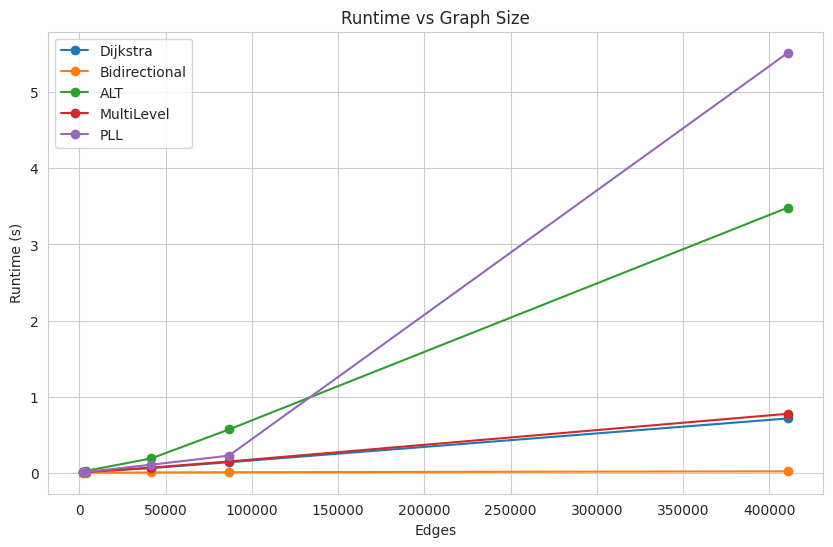

In [147]:
plt.figure(
    figsize=(10,6)
)

for algo in (
    results_df["algorithm"]
    .unique()
):

    subset = (
        results_df[
            results_df["algorithm"]
            == algo
        ]
    )

    plt.plot(
        subset["edges"],
        subset["runtime"],
        marker="o",
        label=algo
    )

#we first graphed nodes VS runtime but then found it didnt scale cleanly since some datasets have higher node count but higher or lower edge count
#instead we decided on edge count
plt.xlabel("Edges")
plt.ylabel("Runtime (s)")
plt.title(
    "Runtime vs Graph Size"
)

plt.legend()
plt.show()

In [150]:
from google.colab import files
folder_path = "gephi_exports"
zip_path = shutil.make_archive("gephi_exports", "zip", folder_path)

files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import networkx as nx
import matplotlib.pyplot as plt
import imageio.v2 as imageio

BASE_DIR = "gephi_exports"
OUTPUT_DIR = "videos"
FPS = 10

os.makedirs(OUTPUT_DIR, exist_ok=True)

for dataset in os.listdir(BASE_DIR):

    dataset_path = os.path.join(BASE_DIR, dataset)

    if not os.path.isdir(dataset_path):
        continue

    for algo in os.listdir(dataset_path):

        folder = os.path.join(dataset_path, algo)

        if not os.path.isdir(folder):
            continue

        print(f"Processing: {dataset} | {algo}")

        files = sorted([
            f for f in os.listdir(folder)
            if f.endswith(".graphml")
        ])

        if len(files) == 0:
            continue

        snapshots = [
            nx.read_graphml(os.path.join(folder, f))
            for f in files
        ]

        final_graph = snapshots[-1]
        pos = nx.spring_layout(final_graph, seed=42)

        frames = []

        for i, G in enumerate(snapshots):

            plt.figure(figsize=(8, 6))

            nx.draw_networkx_edges(G, pos, alpha=0.2, width=1)

            spt_edges = [
                (u, v) for u, v, d in G.edges(data=True)
                if str(d.get("spt")) == "true"
            ]

            nx.draw_networkx_edges(
                G,
                pos,
                edgelist=spt_edges,
                edge_color="red",
                width=2
            )

            visited = [
                n for n, d in G.nodes(data=True)
                if str(d.get("visited")) == "true"
            ]

            others = list(set(G.nodes()) - set(visited))

            nx.draw_networkx_nodes(
                G, pos,
                nodelist=others,
                node_color="lightgray",
                node_size=30
            )

            nx.draw_networkx_nodes(
                G, pos,
                nodelist=visited,
                node_color="green",
                node_size=30
            )

            plt.axis("off")
            plt.tight_layout()

            plt.savefig("frame.png", dpi=120)
            plt.close()

            frames.append(imageio.imread("frame.png"))

        out_name = f"{dataset}_{algo}.mp4"
        out_path = os.path.join(OUTPUT_DIR, out_name)

        imageio.mimsave(out_path, frames, fps=FPS)

        print("Saved:", out_path)

Processing: econ-poli | MultiLevel
Saved: videos/econ-poli_MultiLevel.mp4
Processing: econ-poli | Dijkstra
Saved: videos/econ-poli_Dijkstra.mp4
Processing: econ-poli | Bidirectional
Saved: videos/econ-poli_Bidirectional.mp4
Processing: econ-poli | PLL
Saved: videos/econ-poli_PLL.mp4
Processing: econ-poli | ALT
Saved: videos/econ-poli_ALT.mp4
Processing: econ-wm1 | MultiLevel
Saved: videos/econ-wm1_MultiLevel.mp4
Processing: econ-wm1 | Dijkstra
Saved: videos/econ-wm1_Dijkstra.mp4
Processing: econ-wm1 | Bidirectional
Saved: videos/econ-wm1_Bidirectional.mp4
Processing: econ-wm1 | PLL
Saved: videos/econ-wm1_PLL.mp4
Processing: econ-wm1 | ALT
Saved: videos/econ-wm1_ALT.mp4
Processing: econ-orani678 | MultiLevel
Saved: videos/econ-orani678_MultiLevel.mp4
Processing: econ-orani678 | Dijkstra
Saved: videos/econ-orani678_Dijkstra.mp4
Processing: econ-orani678 | Bidirectional
Saved: videos/econ-orani678_Bidirectional.mp4
Processing: econ-orani678 | PLL
Saved: videos/econ-orani678_PLL.mp4
Proces

In [ ]:
import os
import networkx as nx
import matplotlib.pyplot as plt
import imageio.v2 as imageio


#the runtime crashed as the previous cell used up my ram, this is to save the missing videos due to the crash
BASE_DIR = "gephi_exports"
OUTPUT_DIR = "videos"
FPS = 10

os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGETS = {
    "econ-mbeacxc": None,
    "econ-psmigr1": {
        "Dijkstra",
        "Bidirectional",
        "ALT",
        "PLL"
    }
}

for dataset in TARGETS:

    dataset_path = os.path.join(BASE_DIR, dataset)

    if not os.path.isdir(dataset_path):
        continue

    for algo in os.listdir(dataset_path):

        if TARGETS[dataset] is not None:
            if algo not in TARGETS[dataset]:
                continue

        folder = os.path.join(dataset_path, algo)

        if not os.path.isdir(folder):
            continue

        print(f"Processing: {dataset} | {algo}")

        files = sorted(
            f for f in os.listdir(folder)
            if f.endswith(".graphml")
        )

        if not files:
            continue

        snapshots = [
            nx.read_graphml(os.path.join(folder, f))
            for f in files
        ]

        pos = nx.spring_layout(
            snapshots[-1],
            seed=42
        )

        frames = []

        for G in snapshots:

            plt.figure(figsize=(8, 6))

            nx.draw_networkx_edges(
                G,
                pos,
                alpha=0.2,
                width=1
            )

            spt_edges = [
                (u, v)
                for u, v, d in G.edges(data=True)
                if str(d.get("spt")).lower() == "true"
            ]

            nx.draw_networkx_edges(
                G,
                pos,
                edgelist=spt_edges,
                edge_color="red",
                width=2
            )

            visited = [
                n
                for n, d in G.nodes(data=True)
                if str(d.get("visited")).lower() == "true"
            ]

            others = list(
                set(G.nodes()) - set(visited)
            )

            nx.draw_networkx_nodes(
                G,
                pos,
                nodelist=others,
                node_color="lightgray",
                node_size=30
            )

            nx.draw_networkx_nodes(
                G,
                pos,
                nodelist=visited,
                node_color="green",
                node_size=30
            )

            plt.axis("off")
            plt.tight_layout()

            plt.savefig("frame.png", dpi=120)
            plt.close()

            frames.append(
                imageio.imread("frame.png")
            )

        output_file = os.path.join(
            OUTPUT_DIR,
            f"{dataset}_{algo}.mp4"
        )

        imageio.mimsave(
            output_file,
            frames,
            fps=FPS
        )

        print("Saved:", output_file)

Processing: econ-mbeacxc | MultiLevel
Saved: videos/econ-mbeacxc_MultiLevel.mp4
Processing: econ-mbeacxc | Dijkstra
Saved: videos/econ-mbeacxc_Dijkstra.mp4
Processing: econ-mbeacxc | Bidirectional
Saved: videos/econ-mbeacxc_Bidirectional.mp4
Processing: econ-mbeacxc | PLL
Saved: videos/econ-mbeacxc_PLL.mp4
Processing: econ-mbeacxc | ALT
Saved: videos/econ-mbeacxc_ALT.mp4
Processing: econ-psmigr1 | Dijkstra
Saved: videos/econ-psmigr1_Dijkstra.mp4
Processing: econ-psmigr1 | Bidirectional
Saved: videos/econ-psmigr1_Bidirectional.mp4
Processing: econ-psmigr1 | PLL
Saved: videos/econ-psmigr1_PLL.mp4
Processing: econ-psmigr1 | ALT


In [1]:
import shutil
import os

DEST = "/content/drive/MyDrive/Algorithms_Project"

os.makedirs(DEST, exist_ok=True)

for folder in [
    "videos",
    "gephi_exports",
    "outputs"
]:
    if os.path.exists(folder):
        shutil.copytree(
            folder,
            f"{DEST}/{folder}",
            dirs_exist_ok=True
        )